R² Score: 0.8141
Model saved!


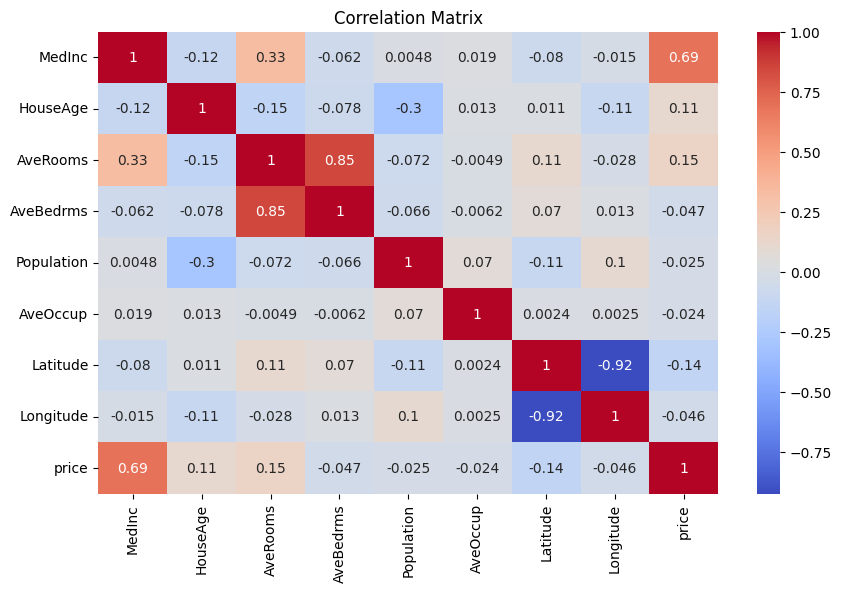

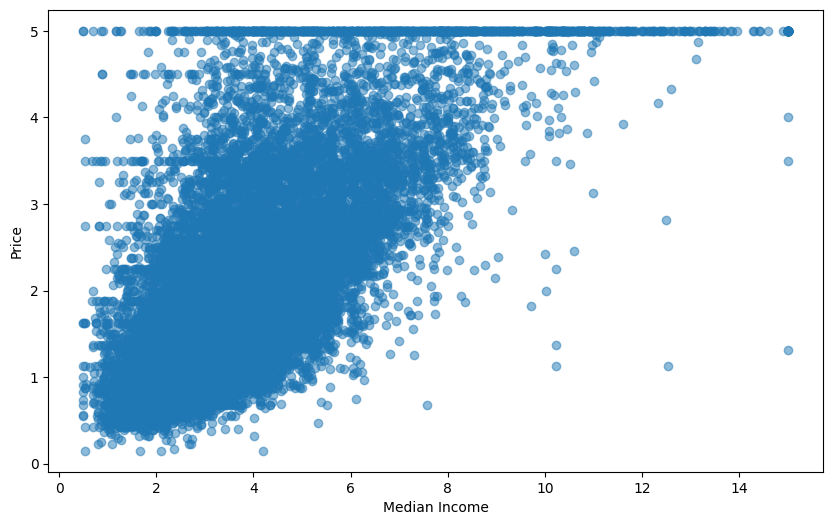

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['price'] = housing.target

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation.png')

plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['price'], alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('Price')
plt.savefig('scatter.png')

X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)
print(f'R2 Score: {score:.4f}')

joblib.dump(model, 'model.pkl')
print('Model saved!')